# 1. Build a basic chatbot using langgraph (GRAPH API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# add_messages is a utility function called as reducers.
# So when we will ask our chatbot questions, it will respons. And we have a state that will be updated with the response. So we will have a state graph that will be updated with the response.
# Now we dont want to overwrite the state graph with the new response, we want to keep the previous state graph and add the new response to it. So we will use the add_messages function to add the new response to the state graph.
# So add_message is one of the reducers that we can use to update the state graph with the new response. We can also use other reducers like set_messages, clear_messages, etc. But for this example, we will use add_messages.

In [2]:
class State(TypedDict):
    messages: Annotated[list[str], add_messages]
    # Annotated is a mechanism to attach arbitrary metadata to type hints without changing how type checkers or the runtime view the underlying type.
    # In the context of LangGraph, your code defines a state where messages is a list of strings, 
    # but it has a special instructor metadata tag ("add_messages") that tells LangGraph how to merge new messages into that list.

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")
# llm=init_chat_model("groq:llama-3.1-8b-instant")

In [5]:
# definition of a node in the graph.
def chatbot(state:State):
    #here the state["messages"] is the input to the llm model. So we are passing the messages to the llm model and getting the response.
    llm_message = llm.invoke(state["messages"]) 
    #here we are returning the response from the llm model and updating the state with the new response. Aka appending the new response to the messages list in the state.
    return {"messages": [llm_message]}

In [6]:
# We are saying the graph that what is the shape of the state by passing the state
# StateGraph is the Graph canvas where we will define the nodes and edges of the graph.
graph_builder = StateGraph(State)

# Adding Node to the graph
graph_builder.add_node("llmchatbot", chatbot)

# Adding edges to the graph
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compiling the graphbuilder
graph = graph_builder.compile()

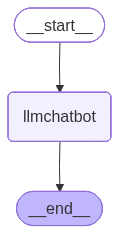

In [7]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
# invoking the graph with initial state
response = graph.invoke({"messages": "Hi"})

In [9]:
# Fetching the last message from the response
last_message = response["messages"][-1].content
last_message

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [10]:
# Streaming a graph with initial state
for event in graph.stream({"messages": "Hi, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

# .invoke()  →  waits for full graph → returns final state (one shot)
# .stream()  →  yields after each node → you get updates as they happen

I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. How about you? How's your day going?


# 2. Chatbot With Tool

In [11]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=2)
tavily_tool.invoke("What is LangGraph?")

{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': '*   [Overview](https://www.ibm.com/think/topics/ai-agents#7281535). *   [What is agentic AI?](https://www.ibm.com/think/topics/agentic-ai#2095054954). *   [Overview](https://www.ibm.com/think/topics/ai-agent-development#1083937704). *   [Building AI agents](https://www.ibm.com/think/topics/how-to-build-an-ai-agent#1083937709). *   [Overview](https://www.ibm.com/think/topics/ai-agent-types#72820454). *   [Overview](https://www.ibm.com/think/topics/components-of-ai-agents#498277090). *   [Communication](https://www.ibm.com/think/topics/ai-agent-communication#498277088). *   [Learning](https://www.ibm.com/think/topics/ai-agent-learning#498277087). *   [Memory](https://www.ibm.com/think/topics/ai-agent-memory#498277086). *   [Perception](https://www.ibm.com/think/topics/ai-agen

In [12]:
# Custom tool function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [13]:
tools = [tavily_tool, multiply]

In [14]:
# binding llm with tools
# This only makes llm know that what are the tools available to it.
llm_with_tools = llm.bind_tools(tools)

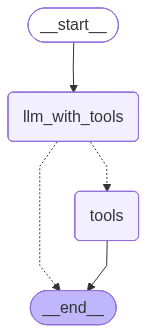

In [22]:
# state graph with tools
# from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


# tool_calling_llm node defination
def tool_calling_llm(state:State):
    # here we are passing the state["messages"] to the llm_with_tools and getting the response. So we are passing the messages to the llm_with_tools and getting the response.
    llm_message = llm_with_tools.invoke(state["messages"])
    # here we are returning the response from the llm_with_tools and updating the state with the new response. Aka appending the new response to the messages list in the state.
    return {"messages": [llm_message]}

# tools node
builder = StateGraph(State)
builder.add_node("llm_with_tools", tool_calling_llm) # creating a node and we are saying that this node is a tool calling llm node and it will invoke the llm_with_tools that we have defined above. So when we will invoke this node, it will invoke the llm_with_tools that we have defined above.
builder.add_node("tools", ToolNode(tools)) # creating a tool node and we are saying that this node is a tool node and it will have the tools that we have defined above. So when we will invoke this node, it will invoke the tools that we have defined above.

builder.add_edge(START, "llm_with_tools")
builder.add_conditional_edges(
    "llm_with_tools",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
# The flow:

# User: "What is 5 * 6?"

# 1. LLM receives the message + knows about [tavily_tool, multiply]
# 2. LLM decides: "I should use multiply for this" -> 
# When you do bind_tools(tools), LangGraph extracts the schema of each tool and sends it to the LLM as part of the API request. That schema includes the function name, description, and parameter types.
# So the LLM isn't guessing — it's reading the tool's description(docstring) and deciding based on that.

# LangGraph converts the tools into a JSON schema and sends it to the LLM API in every request.

# 3. LLM returns an AIMessage with tool_calls field populated:

#    AIMessage(
#      content="",
#      tool_calls=[{
#        "name": "multiply",
#        "args": {"a": 5, "b": 6},
#        "id": "call_abc123"
#      }]
#    )

# 4. tools_condition inspects this AIMessage
# 5. Sees tool_calls is non-empty → routes to "tools" node
# 6. ToolNode executes multiply(5, 6) → returns 30
# 7. Result added to messages as ToolMessage

# LangGraph calls tools_condition(state) after every llm_with_tools node execution, and routes based on what it returns. 
# You're not skipping the condition — tools_condition is the condition, just pre-written for you.

In [37]:
# invoke the graph with initial state
response = graph.invoke({"messages": "What is 5 * 6?"})
response_news = graph.invoke({"messages": "What is latest ai news?"})

In [38]:
# response
response['messages'][-1].content

'30'

In [39]:
# response_news
response_news['messages'][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-waymos-robotaxi-recall", "title": "Fox News AI Newsletter: Waymo\'s robotaxi recall - Fox News", "score": 0.68420124, "published_date": "Fri, 26 Jun 2026 18:02:38 GMT", "content": "SEE THAT?: Meta Wearables VP Alex Himel discusses the newly launched Meta Smart Glasses, highlighting their AI capabilities, accessible price point of $299, and the design collaboration with Kylie Jenner on \\"The Claman Countdown.\\"\\n\\nTECH TITAN: Microsoft CEO Satya Nadella issued a warning that the tech giants competing in the AI race need to ensure they advance the emerging tech in a way that\'s palatable to the public.\\n\\nBOTS MEET BOUNDARIES: NVIDIA, a technology company known for AI computing and robotics systems, has introduced NVIDIA Halos for Robotics. The company calls it the industry\'s first full-stack, comprehensive safety system for roboti

In [40]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 * 6?
================================== Ai Message ==================================
Tool Calls:
  multiply (fcnt7d604)
 Call ID: fcnt7d604
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: multiply

30


In [41]:
for m in response_news['messages']:
    m.pretty_print()

================================ Human Message =================================

What is latest ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (65dx13t5r)
 Call ID: 65dx13t5r
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-waymos-robotaxi-recall", "title": "Fox News AI Newsletter: Waymo's robotaxi recall - Fox News", "score": 0.68420124, "published_date": "Fri, 26 Jun 2026 18:02:38 GMT", "content": "SEE THAT?: Meta Wearables VP Alex Himel discusses the newly launched Meta Smart Glasses, highlighting their AI capabilities, accessible price point of $299, and the design collaboration with Kylie Jenner on \"The Claman Cou

In [45]:
resp=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in resp['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (jdc7xyt7x)
 Call ID: jdc7xyt7x
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (62kgvh3dz)
 Call ID: 62kgvh3dz
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/06/26/how-zai-is-closing-in-on-americas-ai-frontier.html", "title": "How Z.AI is closing in on America's AI frontier - CNBC", "score": 0.7016523, "published_date": "Fri, 26 Jun 2026 21:23:00 GMT", "content": "# How Z.AI is closing in on America's AI frontier. Chinese AI company Zhipu's GLM 5.2 is closing the gap with American frontier model

### ReAct Agent Architecture

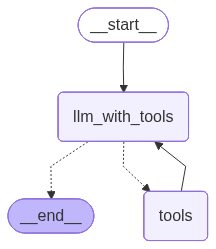

In [ ]:
# state graph with ReAct tools Architecture
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


# tool_calling_llm node defination
def tool_calling_llm(state:State):
    llm_message = llm_with_tools.invoke(state["messages"])
    return {"messages": [llm_message]}

# tools node
builder = StateGraph(State)
builder.add_node("llm_with_tools", tool_calling_llm)
builder.add_node("tools", ToolNode(tools)) 

builder.add_edge(START, "llm_with_tools")
builder.add_conditional_edges(
    "llm_with_tools",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","llm_with_tools") # We are creating a cycle 

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
resp=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in resp['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (x0fhrtcgr)
 Call ID: x0fhrtcgr
  Args:
    query: recent AI news
    topic: news
  multiply (mgycczre1)
 Call ID: mgycczre1
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/06/24/companies-are-scrambling-to-stop-employees-from-maxing-out-ai-budgets-with-small-tasks/", "title": "Companies are scrambling to stop employees from maxing out AI budgets with small tasks - TechCrunch", "score": 0.8051581, "published_date": "Wed, 24 Jun 2026 20:09:45 GMT", "content": "Founder Summit ticket savings of up to $190 end June 26. After the AI indus

# 3. Adding Memory in the Agentic graph

In [ ]:
resp=graph.invoke({"messages":"hi, My name is Kaushik Mandal"})
for m in resp['messages']:
    m.pretty_print()

# Even though llm reads my name, still it wont able to respond in next llm call as it has no memory, aka cant persist the meory.

================================ Human Message =================================

hi, My name is Kaushik Mandal
================================== Ai Message ==================================

Nice to meet you Kaushik Mandal! How can I assist you today?


In [55]:
resp=graph.invoke({"messages":"what is my name?"})
for m in resp['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (psfhmcv7z)
 Call ID: psfhmcv7z
  Args:
    query: my name
================================= Tool Message =================================
Name: tavily_search

{"query": "my name", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://wildsoundfestivalreview.com/2025/11/21/tv-review-my-name-netflix-series", "title": "TV Review: MY NAME (Netflix Series) – WILDsound Festival", "content": "I’m afraid of not knowing the truth.” — Yoon Ji-woo*. *My Name* is one of those K-dramas that grabs your attention from the start and maintains a relentless pace throughout. It is a gritty, action-packed series set in a dark, unforgiving underworld marked by crime, betrayal, and a driving quest for revenge. The story follows Yoon Ji-woo, a young woman whose life is

In [ ]:
# If you see the o/p, it wont able to respond with my name as it has no memory, aka cant persist the meory.

In [ ]:
# Persisting the state
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# memory import
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver() #in-memory checkpoint saver. You can also use a file-based saver or a database-based saver.


# tool_calling_llm node defination
def tool_calling_llm(state:State):
    llm_message = llm_with_tools.invoke(state["messages"])
    return {"messages": [llm_message]}

# tools node
builder = StateGraph(State)
builder.add_node("llm_with_tools", tool_calling_llm)
builder.add_node("tools", ToolNode(tools)) 

builder.add_edge(START, "llm_with_tools")
builder.add_conditional_edges(
    "llm_with_tools",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","llm_with_tools") # We are creating a cycle 

## compile the graph
graph=builder.compile(checkpointer=memory) # passing the memory to the graph so that it can persist the state.

In [60]:
# We have to assign a unique thread_id to each conversation. This allows the graph to maintain separate states for different conversations. If you use the same thread_id, the graph will continue the conversation from where it left off. If you use a different thread_id, it will start a new conversation.
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Kaushik"},config=config)
print(response['messages'][-1].content)

Hello Kaushik, it seems like we just had a name mix-up earlier. Your name is now Kaushik.


In [62]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)
print(response['messages'][-1].content)

Your name is Kaushik.
